In [2]:
import kagglehub

path = kagglehub.dataset_download("behrad3d/nasa-cmaps")
print(path)

/home/vscode/.cache/kagglehub/datasets/behrad3d/nasa-cmaps/versions/1


In [3]:
import os
path = "/home/vscode/.cache/kagglehub/datasets/behrad3d/nasa-cmaps/versions/1"
print(os.listdir(path))

['CMaps']


In [4]:
import os
path = "/home/vscode/.cache/kagglehub/datasets/behrad3d/nasa-cmaps/versions/1"
print(os.listdir(f"{path}/CMaps"))

['RUL_FD004.txt', 'RUL_FD002.txt', 'RUL_FD001.txt', 'RUL_FD003.txt', 'test_FD003.txt', 'train_FD002.txt', 'test_FD002.txt', 'Damage Propagation Modeling.pdf', 'readme.txt', 'train_FD003.txt', 'test_FD004.txt', 'train_FD001.txt', 'train_FD004.txt', 'test_FD001.txt', 'x.txt']


In [5]:
import os
path = "/home/vscode/.cache/kagglehub/datasets/behrad3d/nasa-cmaps/versions/1"

for root, dirs, files in os.walk(path):
    for file in files:
        print(os.path.join(root, file))
        

/home/vscode/.cache/kagglehub/datasets/behrad3d/nasa-cmaps/versions/1/CMaps/RUL_FD004.txt
/home/vscode/.cache/kagglehub/datasets/behrad3d/nasa-cmaps/versions/1/CMaps/RUL_FD002.txt
/home/vscode/.cache/kagglehub/datasets/behrad3d/nasa-cmaps/versions/1/CMaps/RUL_FD001.txt
/home/vscode/.cache/kagglehub/datasets/behrad3d/nasa-cmaps/versions/1/CMaps/RUL_FD003.txt
/home/vscode/.cache/kagglehub/datasets/behrad3d/nasa-cmaps/versions/1/CMaps/test_FD003.txt
/home/vscode/.cache/kagglehub/datasets/behrad3d/nasa-cmaps/versions/1/CMaps/train_FD002.txt
/home/vscode/.cache/kagglehub/datasets/behrad3d/nasa-cmaps/versions/1/CMaps/test_FD002.txt
/home/vscode/.cache/kagglehub/datasets/behrad3d/nasa-cmaps/versions/1/CMaps/Damage Propagation Modeling.pdf
/home/vscode/.cache/kagglehub/datasets/behrad3d/nasa-cmaps/versions/1/CMaps/readme.txt
/home/vscode/.cache/kagglehub/datasets/behrad3d/nasa-cmaps/versions/1/CMaps/train_FD003.txt
/home/vscode/.cache/kagglehub/datasets/behrad3d/nasa-cmaps/versions/1/CMaps/tes

In [6]:
import pandas as pd

path = "/home/vscode/.cache/kagglehub/datasets/behrad3d/nasa-cmaps/versions/1/CMaps"

# Nombres de columnas del dataset NASA CMAPSS
columnas = ['unit_id', 'cycle', 'op_setting_1', 'op_setting_2', 'op_setting_3'] + \
           [f'sensor_{i}' for i in range(1, 22)]

# Cargar archivo de entrenamiento
df = pd.read_csv(f"{path}/train_FD001.txt", sep='\s+', header=None, names=columnas)

print(df.shape)
print(df.head())
print(df.info())

(20631, 26)
   unit_id  cycle  op_setting_1  op_setting_2  op_setting_3  sensor_1  \
0        1      1       -0.0007       -0.0004         100.0    518.67   
1        1      2        0.0019       -0.0003         100.0    518.67   
2        1      3       -0.0043        0.0003         100.0    518.67   
3        1      4        0.0007        0.0000         100.0    518.67   
4        1      5       -0.0019       -0.0002         100.0    518.67   

   sensor_2  sensor_3  sensor_4  sensor_5  ...  sensor_12  sensor_13  \
0    641.82   1589.70   1400.60     14.62  ...     521.66    2388.02   
1    642.15   1591.82   1403.14     14.62  ...     522.28    2388.07   
2    642.35   1587.99   1404.20     14.62  ...     522.42    2388.03   
3    642.35   1582.79   1401.87     14.62  ...     522.86    2388.08   
4    642.37   1582.85   1406.22     14.62  ...     522.19    2388.04   

   sensor_14  sensor_15  sensor_16  sensor_17  sensor_18  sensor_19  \
0    8138.62     8.4195       0.03        392

In [7]:
import pandas as pd

path = "/home/vscode/.cache/kagglehub/datasets/behrad3d/nasa-cmaps/versions/1/CMaps"

columnas = ['unit_id', 'cycle', 'op_setting_1', 'op_setting_2', 'op_setting_3'] + \
           [f'sensor_{i}' for i in range(1, 22)]

# Cargar los 4 archivos y combinarlos
df1 = pd.read_csv(f"{path}/train_FD001.txt", sep='\s+', header=None, names=columnas)
df2 = pd.read_csv(f"{path}/train_FD002.txt", sep='\s+', header=None, names=columnas)
df3 = pd.read_csv(f"{path}/train_FD003.txt", sep='\s+', header=None, names=columnas)
df4 = pd.read_csv(f"{path}/train_FD004.txt", sep='\s+', header=None, names=columnas)

# Agregar columna para identificar de qué dataset viene
df1['dataset'] = 'FD001'
df2['dataset'] = 'FD002'
df3['dataset'] = 'FD003'
df4['dataset'] = 'FD004'

# Combinar todos
df = pd.concat([df1, df2, df3, df4], ignore_index=True)

print(f"Total filas: {df.shape[0]}")
print(f"Total columnas: {df.shape[1]}")
print(df.head())

Total filas: 160359
Total columnas: 27
   unit_id  cycle  op_setting_1  op_setting_2  op_setting_3  sensor_1  \
0        1      1       -0.0007       -0.0004         100.0    518.67   
1        1      2        0.0019       -0.0003         100.0    518.67   
2        1      3       -0.0043        0.0003         100.0    518.67   
3        1      4        0.0007        0.0000         100.0    518.67   
4        1      5       -0.0019       -0.0002         100.0    518.67   

   sensor_2  sensor_3  sensor_4  sensor_5  ...  sensor_13  sensor_14  \
0    641.82   1589.70   1400.60     14.62  ...    2388.02    8138.62   
1    642.15   1591.82   1403.14     14.62  ...    2388.07    8131.49   
2    642.35   1587.99   1404.20     14.62  ...    2388.03    8133.23   
3    642.35   1582.79   1401.87     14.62  ...    2388.08    8133.83   
4    642.37   1582.85   1406.22     14.62  ...    2388.04    8133.80   

   sensor_15  sensor_16  sensor_17  sensor_18  sensor_19  sensor_20  \
0     8.4195      

In [8]:
# Crear variable objetivo RUL (Remaining Useful Life)
max_cycles = df.groupby(['dataset', 'unit_id'])['cycle'].max().reset_index()
max_cycles.columns = ['dataset', 'unit_id', 'max_cycle']

df = df.merge(max_cycles, on=['dataset', 'unit_id'])
df['RUL'] = df['max_cycle'] - df['cycle']
df = df.drop(columns=['max_cycle'])

print(df.shape)
print(df[['unit_id', 'cycle', 'RUL']].head(10))
print(f"\nRUL min: {df['RUL'].min()}")
print(f"RUL max: {df['RUL'].max()}")
print(f"RUL promedio: {df['RUL'].mean():.2f}")

(160359, 28)
   unit_id  cycle  RUL
0        1      1  191
1        1      2  190
2        1      3  189
3        1      4  188
4        1      5  187
5        1      6  186
6        1      7  185
7        1      8  184
8        1      9  183
9        1     10  182

RUL min: 0
RUL max: 542
RUL promedio: 122.33


📊 FORMA DEL DATASET
Filas:    160359
Columnas: 28

📋 TIPOS DE DATOS
unit_id           int64
cycle             int64
op_setting_1    float64
op_setting_2    float64
op_setting_3    float64
sensor_1        float64
sensor_2        float64
sensor_3        float64
sensor_4        float64
sensor_5        float64
sensor_6        float64
sensor_7        float64
sensor_8        float64
sensor_9        float64
sensor_10       float64
sensor_11       float64
sensor_12       float64
sensor_13       float64
sensor_14       float64
sensor_15       float64
sensor_16       float64
sensor_17         int64
sensor_18         int64
sensor_19       float64
sensor_20       float64
sensor_21       float64
dataset          object
RUL               int64
dtype: object

❌ VALORES NULOS
✅ No hay valores nulos

📈 ESTADÍSTICAS DESCRIPTIVAS
         unit_id      cycle  op_setting_1  op_setting_2  op_setting_3  \
count  160359.00  160359.00     160359.00     160359.00     160359.00   
mean      105.55     123.33    

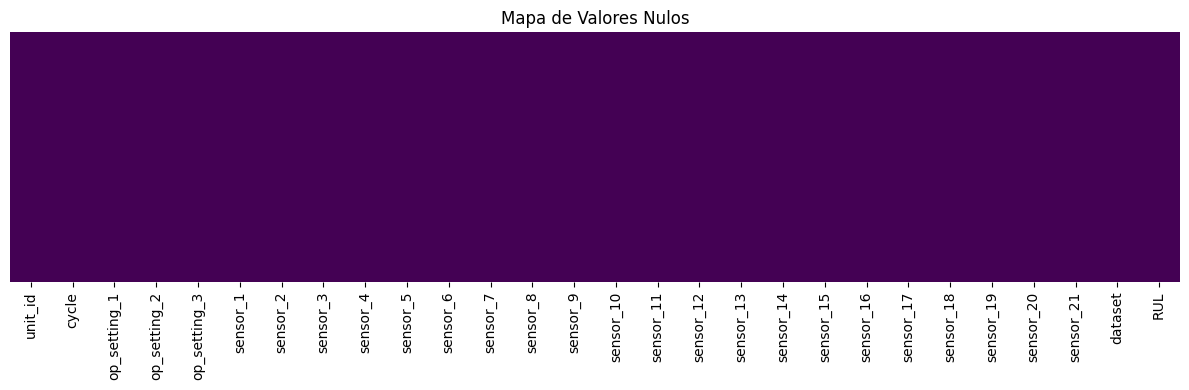

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("=" * 50)
print("📊 FORMA DEL DATASET")
print("=" * 50)
print(f"Filas:    {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")

print("\n" + "=" * 50)
print("📋 TIPOS DE DATOS")
print("=" * 50)
print(df.dtypes)

print("\n" + "=" * 50)
print("❌ VALORES NULOS")
print("=" * 50)
nulos = df.isnull().sum()
print(nulos[nulos > 0] if nulos.sum() > 0 else "✅ No hay valores nulos")

print("\n" + "=" * 50)
print("📈 ESTADÍSTICAS DESCRIPTIVAS")
print("=" * 50)
print(df.describe().round(2))

# Gráfica de valores nulos
plt.figure(figsize=(12, 4))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Mapa de Valores Nulos')
plt.tight_layout()
plt.show()


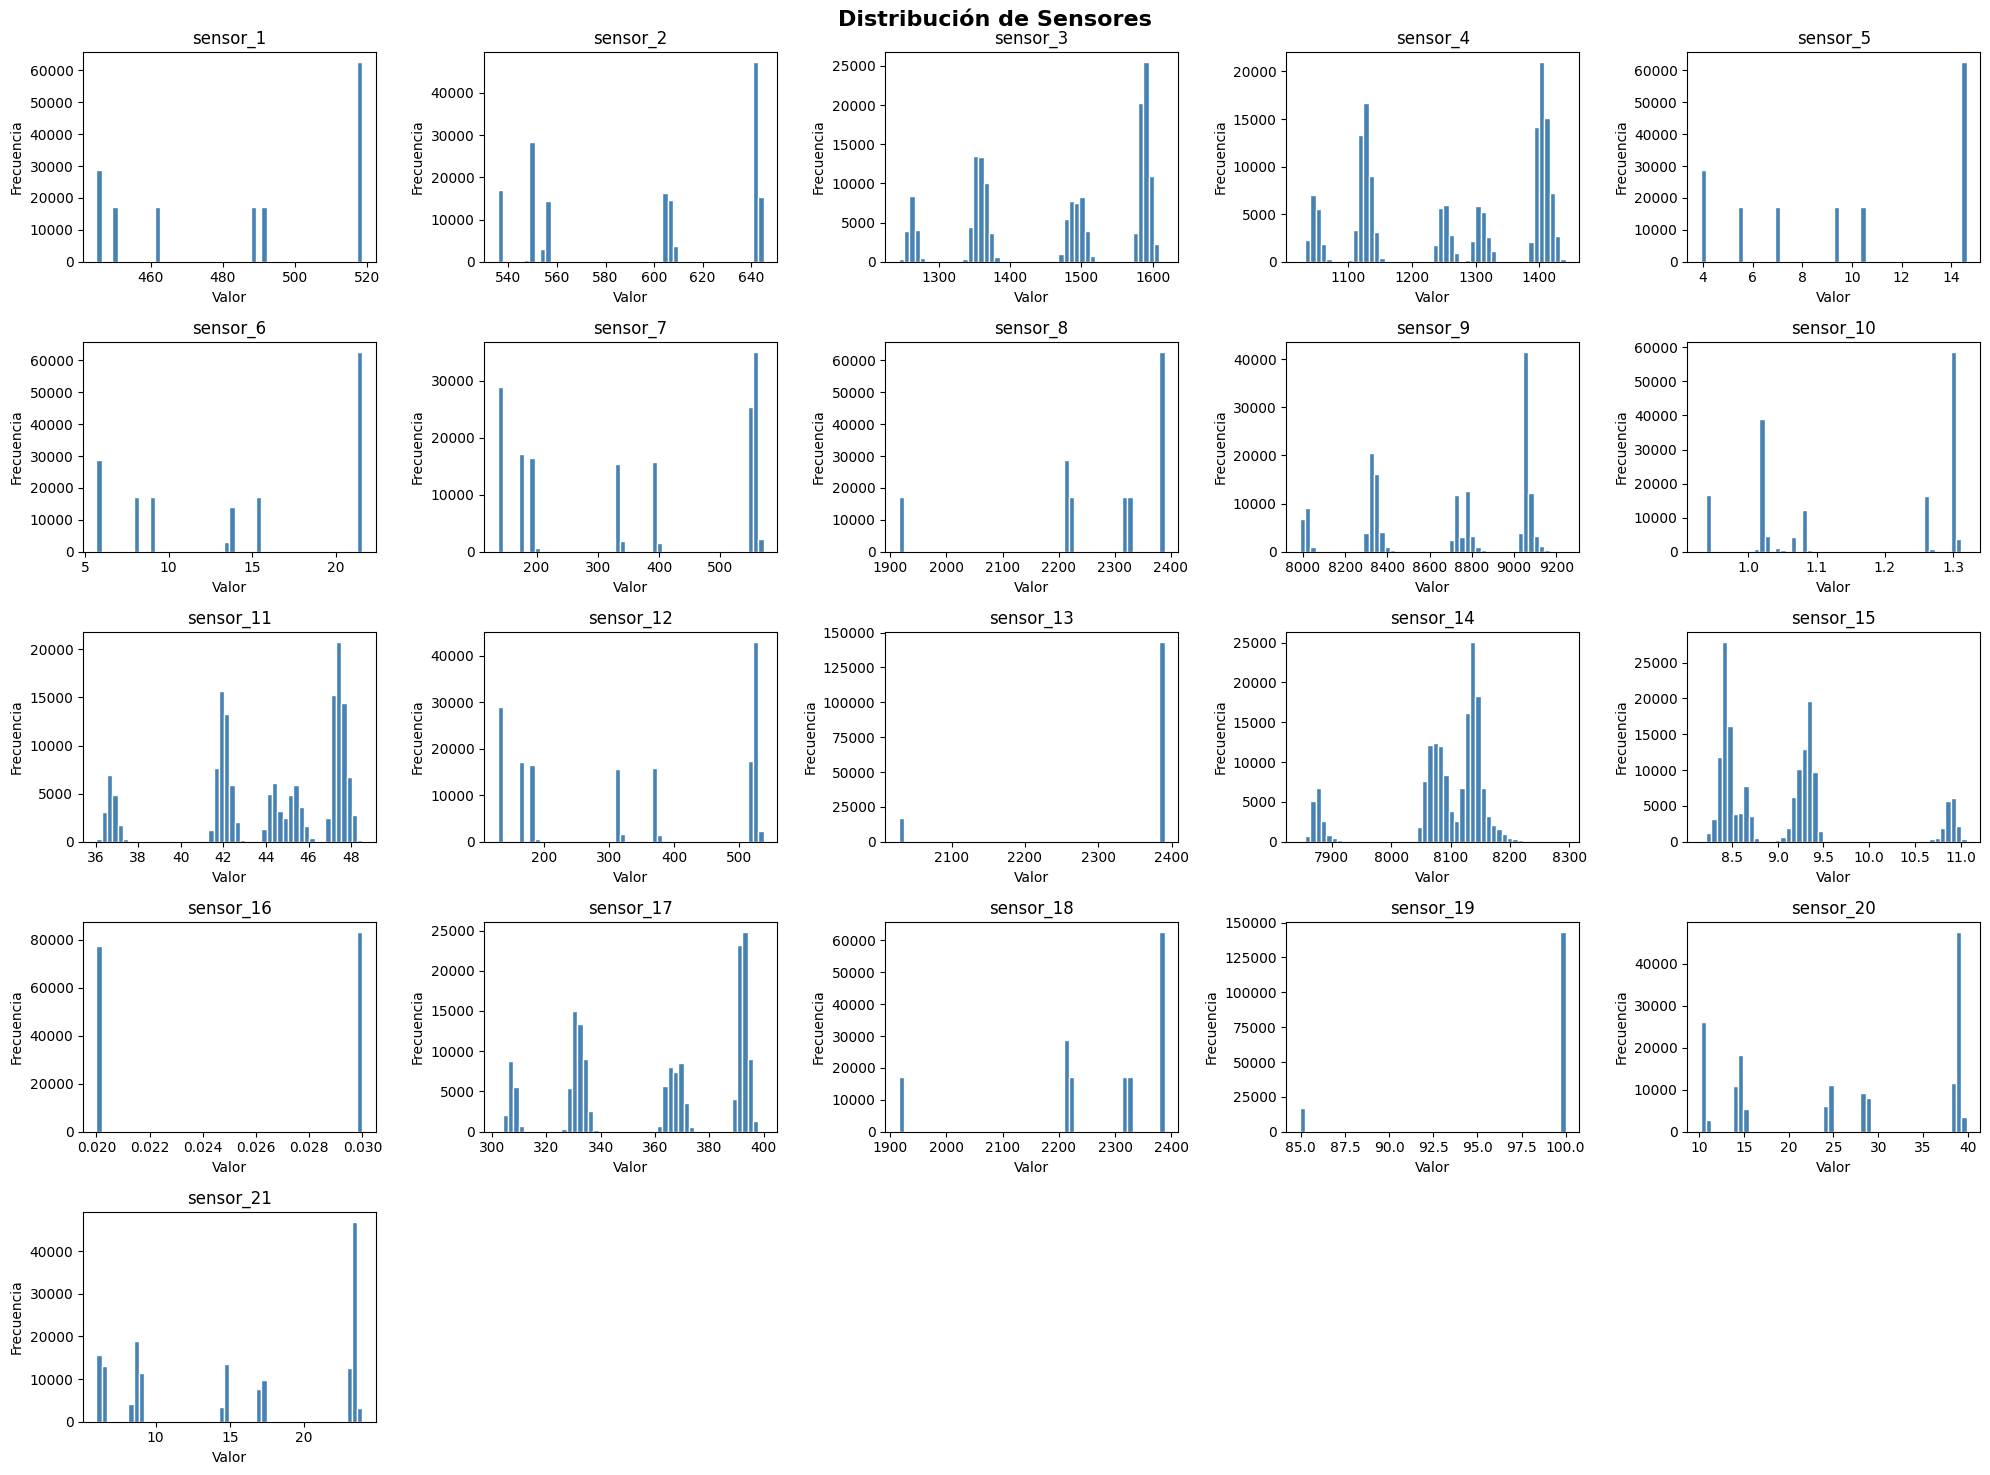

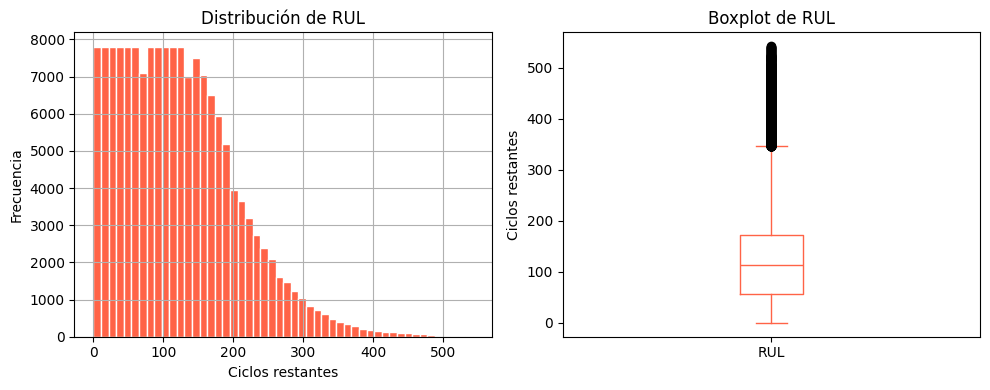

In [10]:
import matplotlib.pyplot as plt

# Sensores a graficar
sensores = [f'sensor_{i}' for i in range(1, 22)]
operaciones = ['op_setting_1', 'op_setting_2', 'op_setting_3']

# Distribución de sensores
fig, axes = plt.subplots(5, 5, figsize=(20, 15))
axes = axes.flatten()

for i, sensor in enumerate(sensores):
    axes[i].hist(df[sensor], bins=50, color='steelblue', edgecolor='white')
    axes[i].set_title(sensor)
    axes[i].set_xlabel('Valor')
    axes[i].set_ylabel('Frecuencia')

# Ocultar subplots vacíos
for j in range(len(sensores), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribución de Sensores', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Distribución del objetivo RUL
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
df['RUL'].hist(bins=50, color='tomato', edgecolor='white')
plt.title('Distribución de RUL')
plt.xlabel('Ciclos restantes')
plt.ylabel('Frecuencia')

plt.subplot(1, 2, 2)
df['RUL'].plot(kind='box', color='tomato')
plt.title('Boxplot de RUL')
plt.ylabel('Ciclos restantes')

plt.tight_layout()
plt.show()


📊 Varianza de cada sensor:
sensor_16         0.0000
sensor_10         0.0202
sensor_15         0.5649
sensor_11        11.7398
sensor_5         18.1950
sensor_19        21.6808
sensor_6         41.5241
sensor_21        49.2112
sensor_20       136.6893
sensor_1        925.4000
sensor_17       962.3291
sensor_2       1804.4244
sensor_14      6500.1096
sensor_13     12358.1558
sensor_3      13965.3922
sensor_4      18577.7098
sensor_8      20285.3402
sensor_18     20309.9878
sensor_12     26959.4990
sensor_7      30322.5925
sensor_9     140368.2076
dtype: float64


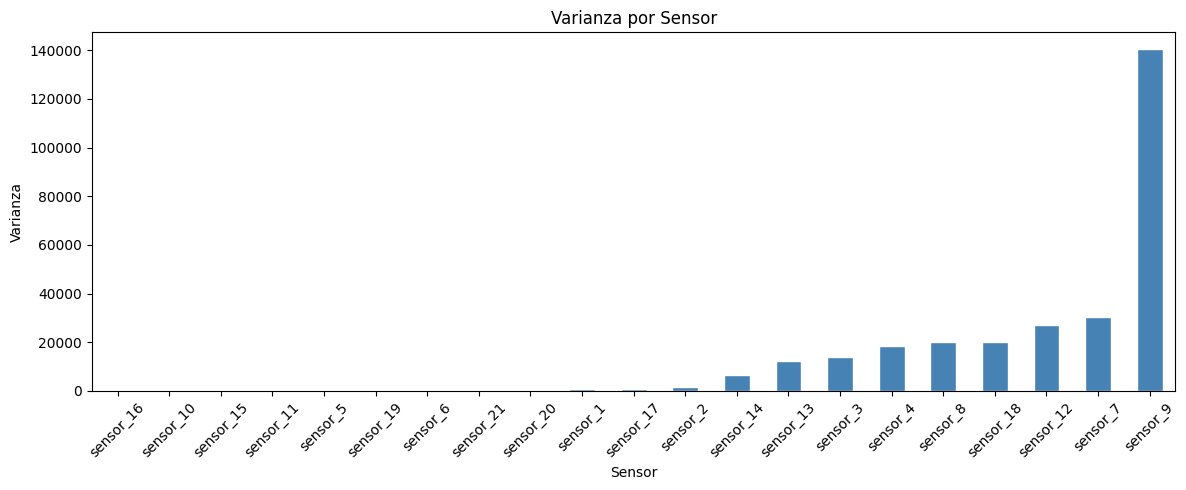


❌ Sensores con varianza baja (descartar): ['sensor_16']

✅ Sensores útiles para el modelo: ['sensor_10', 'sensor_15', 'sensor_11', 'sensor_5', 'sensor_19', 'sensor_6', 'sensor_21', 'sensor_20', 'sensor_1', 'sensor_17', 'sensor_2', 'sensor_14', 'sensor_13', 'sensor_3', 'sensor_4', 'sensor_8', 'sensor_18', 'sensor_12', 'sensor_7', 'sensor_9']


In [11]:
#RMC 3000 POR ENCIMA O POR DEBAJO DE 0.01. Si es por debajo, el sensor no aporta información útil para predecir el RUL y se puede descartar. Si es por encima, el sensor tiene variabilidad suficiente para ser considerado en el modelo.

#FEATURE EncodingWarning


# Calcular varianza de cada sensor
varianza = df[sensores].var().sort_values()

print("📊 Varianza de cada sensor:")
print(varianza.round(4))

# Gráfica de varianza
plt.figure(figsize=(12, 5))
varianza.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Varianza por Sensor')
plt.xlabel('Sensor')
plt.ylabel('Varianza')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Identificar sensores con varianza muy baja (casi constantes)
umbral = 0.01
sensores_bajos = varianza[varianza < umbral].index.tolist()
sensores_utiles = varianza[varianza >= umbral].index.tolist()

print(f"\n❌ Sensores con varianza baja (descartar): {sensores_bajos}")
print(f"\n✅ Sensores útiles para el modelo: {sensores_utiles}")

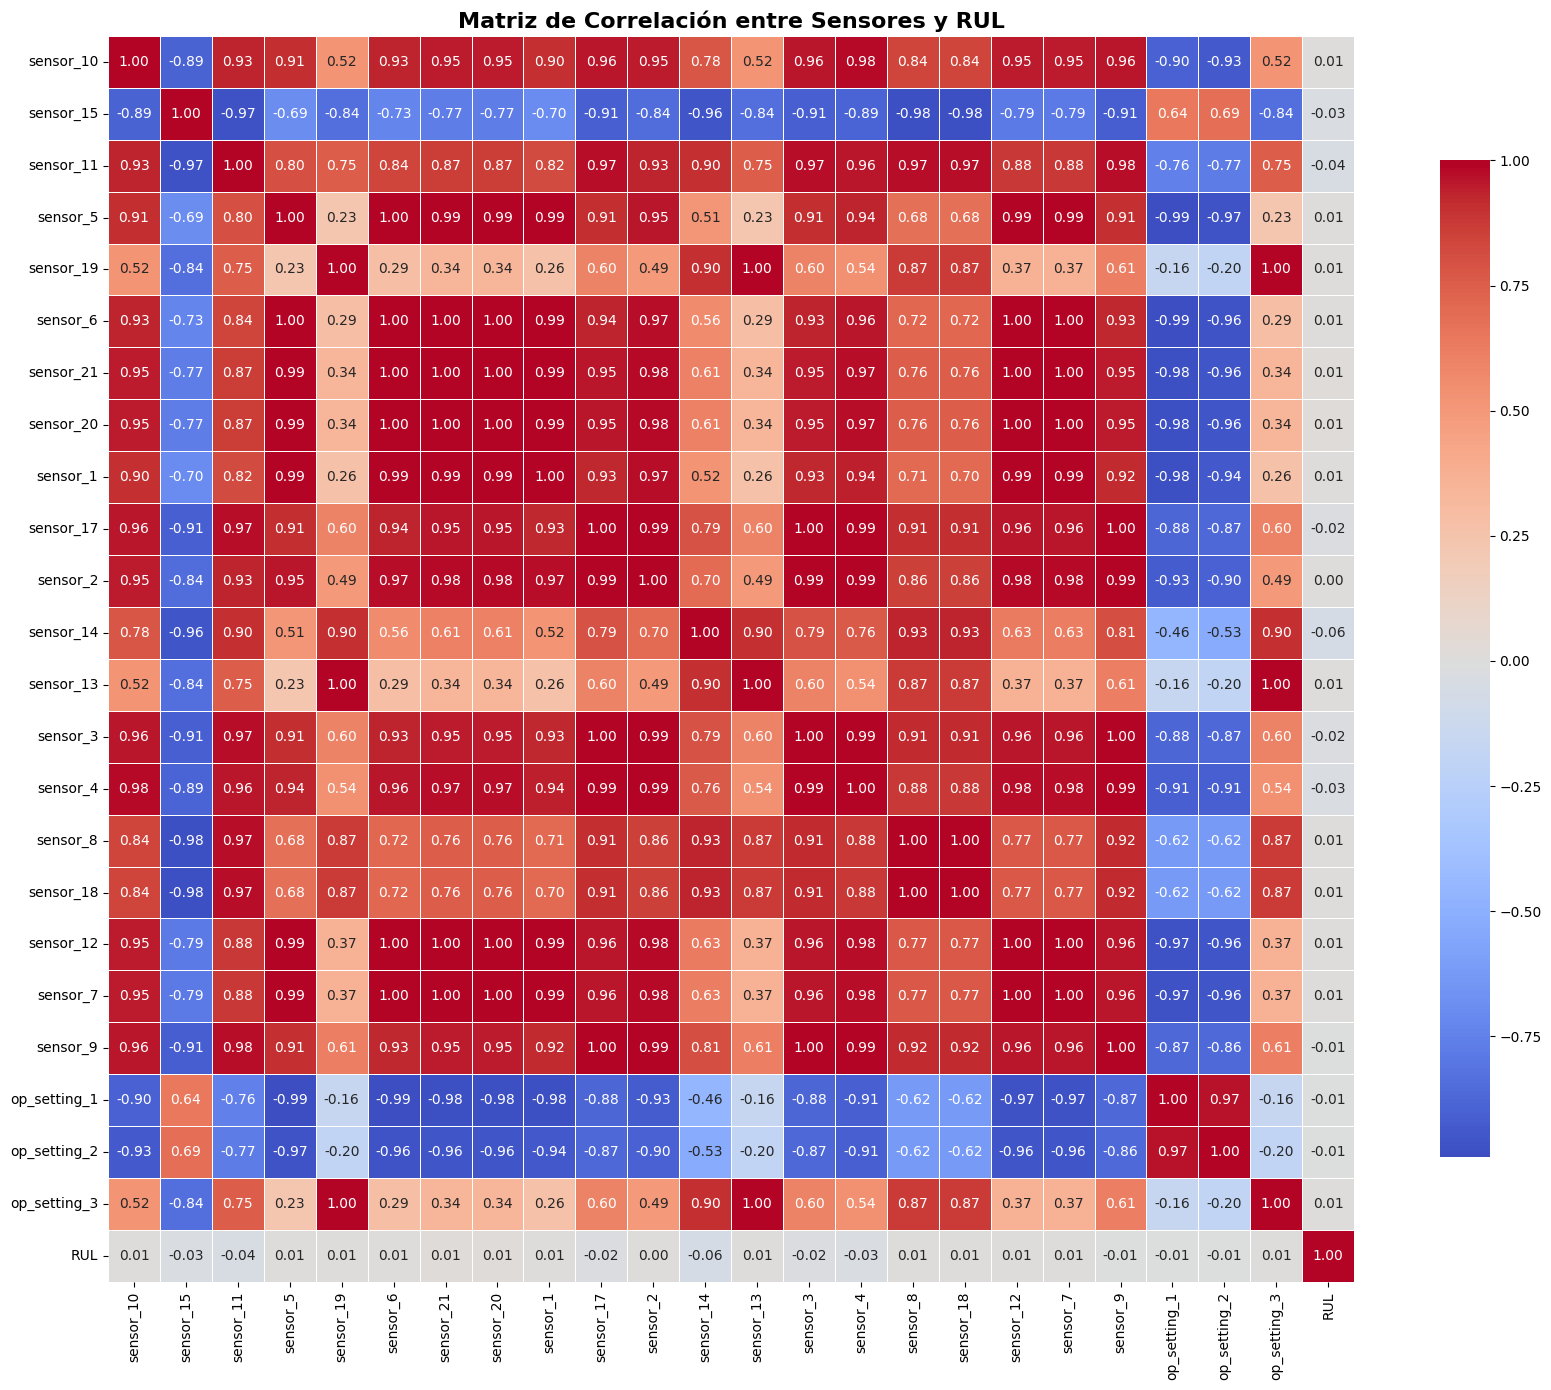

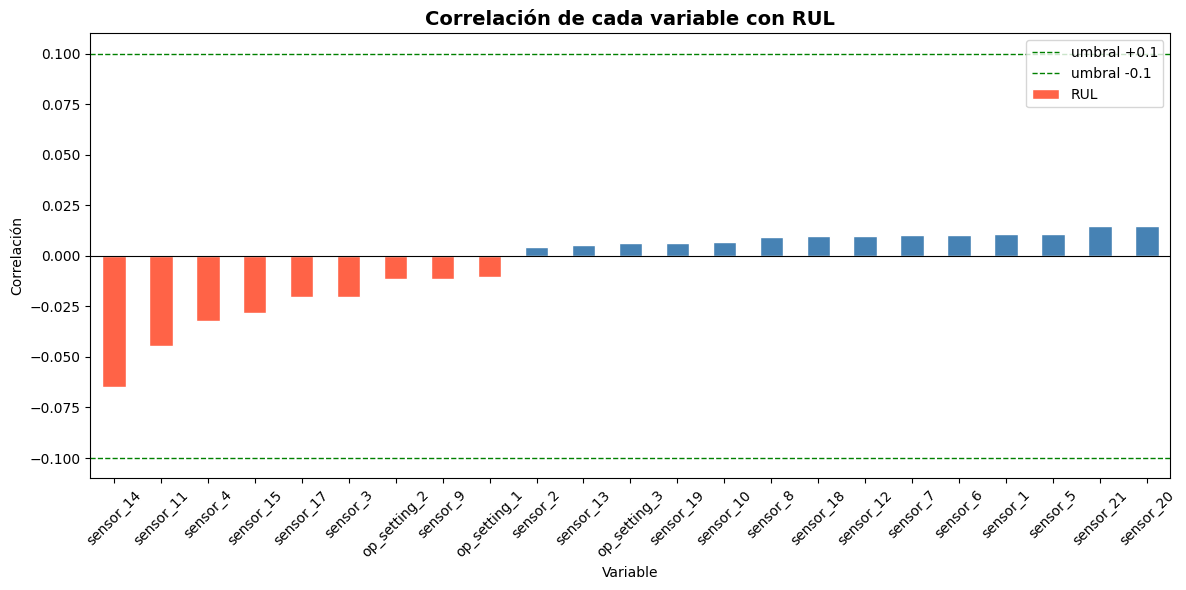

🔝 Variables más correlacionadas con RUL:
sensor_14       0.064813
sensor_11       0.044859
sensor_4        0.032047
sensor_15       0.028528
sensor_17       0.020581
sensor_3        0.020455
sensor_20       0.014697
sensor_21       0.014656
op_setting_2    0.011275
sensor_9        0.011261
Name: RUL, dtype: float64


In [12]:
#Paso 4 — Correlación entre variables:
import seaborn as sns
import matplotlib.pyplot as plt

# Seleccionar solo columnas numéricas relevantes
cols_corr = sensores_utiles + ['op_setting_1', 'op_setting_2', 'op_setting_3', 'RUL']

# Matriz de correlación
corr_matrix = df[cols_corr].corr()

# Heatmap completo
plt.figure(figsize=(18, 14))
sns.heatmap(corr_matrix, 
            annot=True, 
            fmt='.2f', 
            cmap='coolwarm',
            center=0,
            square=True,
            linewidths=0.5,
            cbar_kws={"shrink": 0.8})
plt.title('Matriz de Correlación entre Sensores y RUL', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Correlación específica con RUL (lo más importante)
corr_rul = corr_matrix['RUL'].drop('RUL').sort_values()

plt.figure(figsize=(12, 6))
corr_rul.plot(kind='bar', 
              color=['tomato' if x < 0 else 'steelblue' for x in corr_rul],
              edgecolor='white')
plt.title('Correlación de cada variable con RUL', fontsize=14, fontweight='bold')
plt.xlabel('Variable')
plt.ylabel('Correlación')
plt.axhline(y=0, color='black', linewidth=0.8)
plt.axhline(y=0.1, color='green', linewidth=1, linestyle='--', label='umbral +0.1')
plt.axhline(y=-0.1, color='green', linewidth=1, linestyle='--', label='umbral -0.1')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Mostrar las más correlacionadas con RUL
print("🔝 Variables más correlacionadas con RUL:")
print(corr_rul.abs().sort_values(ascending=False).head(10))

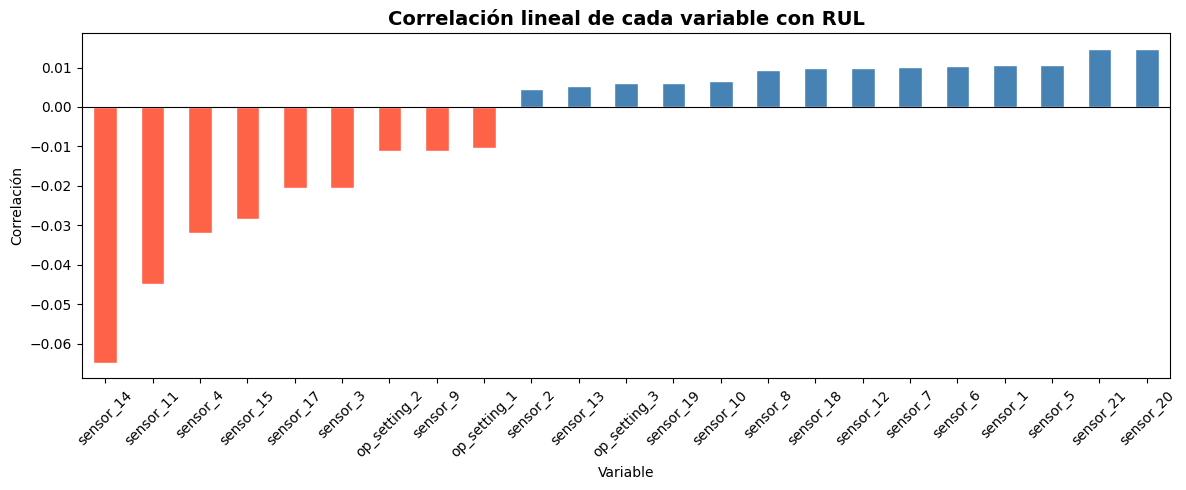

📊 Correlación con RUL:
sensor_14       0.064813
sensor_11       0.044859
sensor_4        0.032047
sensor_15       0.028528
sensor_17       0.020581
sensor_3        0.020455
sensor_20       0.014697
sensor_21       0.014656
op_setting_2    0.011275
sensor_9        0.011261
sensor_5        0.010733
sensor_1        0.010684
sensor_6        0.010477
op_setting_1    0.010300
sensor_7        0.010196
sensor_12       0.009980
sensor_18       0.009915
sensor_8        0.009345
sensor_10       0.006582
sensor_19       0.006096
op_setting_3    0.006096
sensor_13       0.005335
sensor_2        0.004582
Name: RUL, dtype: float64


In [13]:
# Correlación con RUL ordenada
corr_rul = df[cols_corr].corr()['RUL'].drop('RUL').sort_values()

plt.figure(figsize=(12, 5))
corr_rul.plot(kind='bar',
              color=['tomato' if x < 0 else 'steelblue' for x in corr_rul],
              edgecolor='white')
plt.title('Correlación lineal de cada variable con RUL', fontsize=14, fontweight='bold')
plt.axhline(y=0, color='black', linewidth=0.8)
plt.xlabel('Variable')
plt.ylabel('Correlación')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("📊 Correlación con RUL:")
print(corr_rul.abs().sort_values(ascending=False))

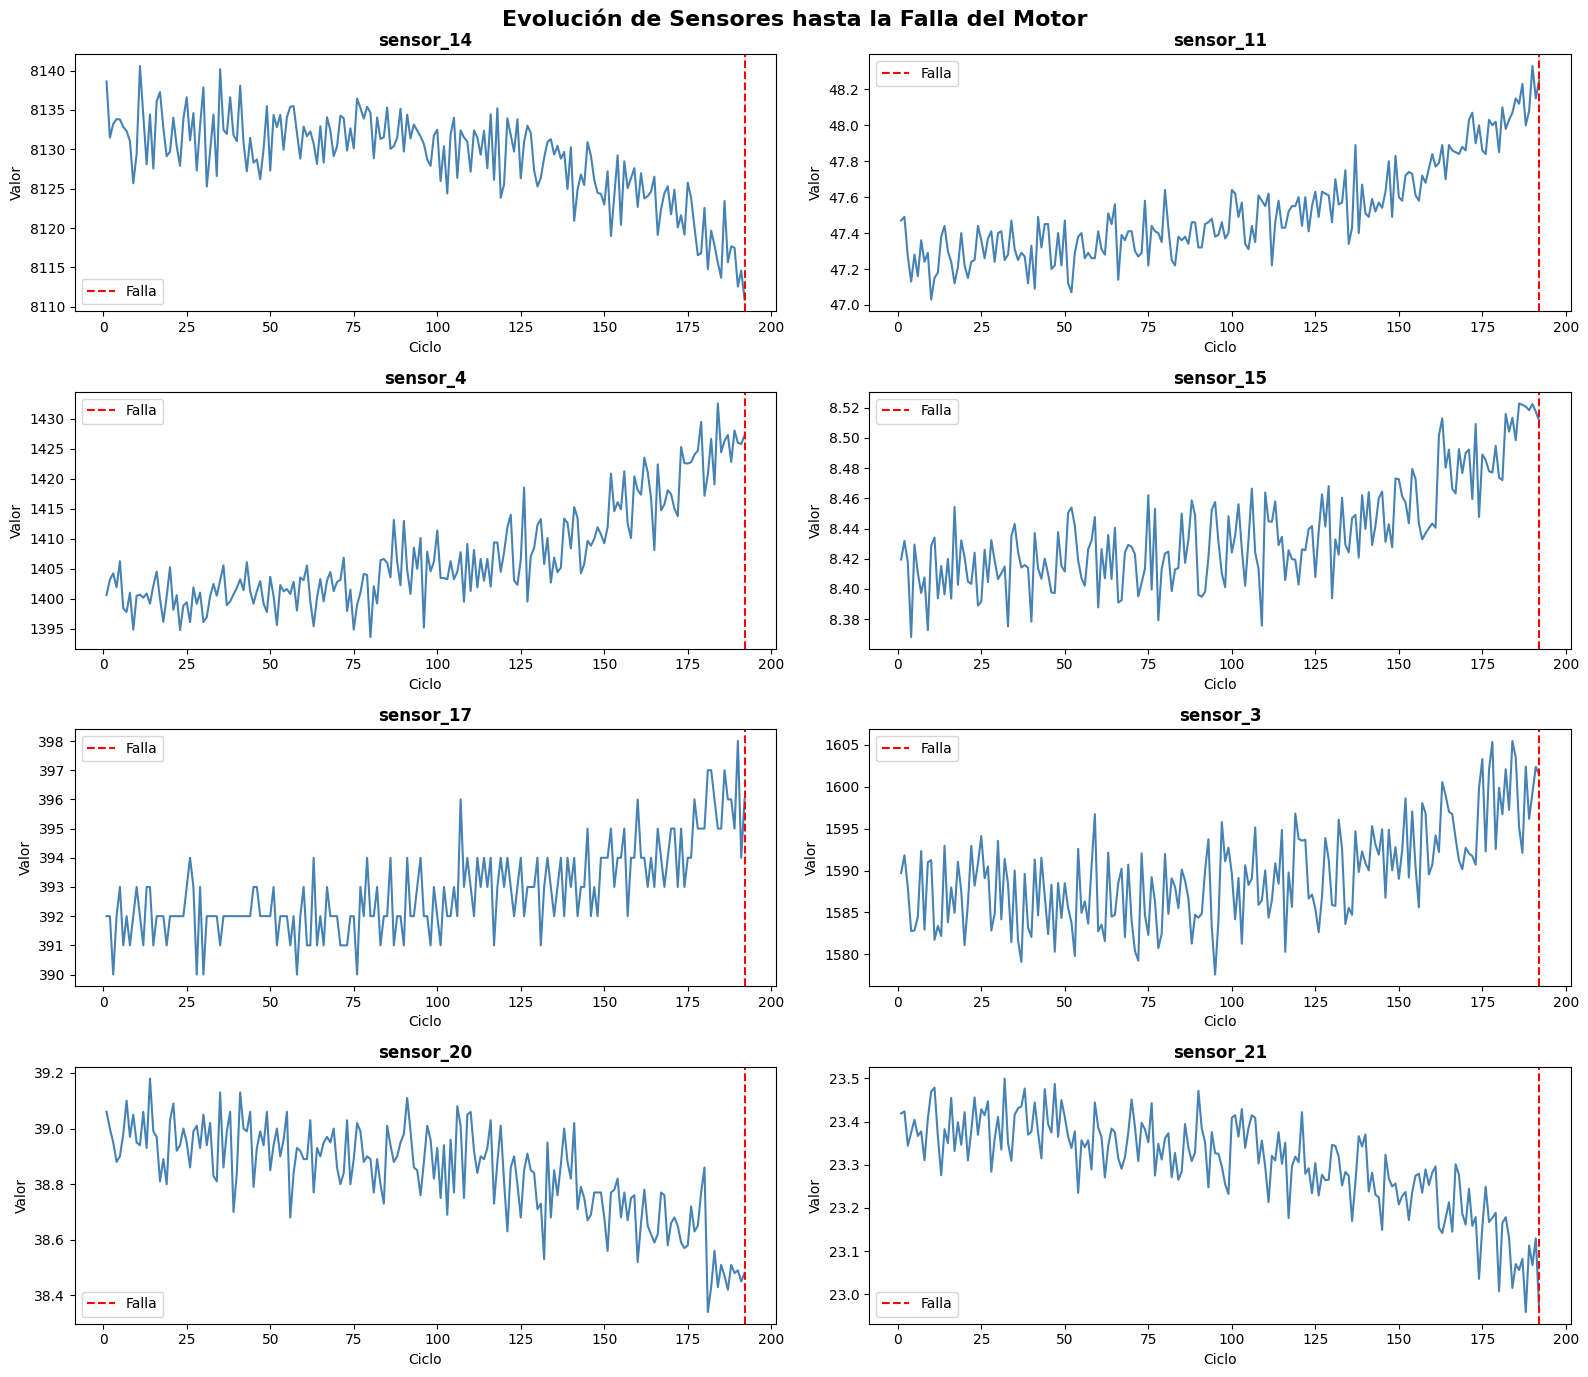

In [14]:
# Tomar un solo motor para ver cómo evolucionan los sensores hasta la falla
motor = df[(df['unit_id'] == 1) & (df['dataset'] == 'FD001')]

# Sensores más correlacionados con RUL
sensores_top = ['sensor_14', 'sensor_11', 'sensor_4', 'sensor_15', 
                'sensor_17', 'sensor_3', 'sensor_20', 'sensor_21']

fig, axes = plt.subplots(4, 2, figsize=(16, 14))
axes = axes.flatten()

for i, sensor in enumerate(sensores_top):
    axes[i].plot(motor['cycle'], motor[sensor], color='steelblue', linewidth=1.5)
    axes[i].axvline(x=motor['cycle'].max(), color='red', linestyle='--', label='Falla')
    axes[i].set_title(f'{sensor}', fontweight='bold')
    axes[i].set_xlabel('Ciclo')
    axes[i].set_ylabel('Valor')
    axes[i].legend()

plt.suptitle('Evolución de Sensores hasta la Falla del Motor', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [15]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Variables predictoras y objetivo
features = ['cycle', 'op_setting_1', 'op_setting_2', 'op_setting_3'] + \
           [f'sensor_{i}' for i in range(1, 22)]

X = df[features]
y = df['RUL']

# Dividir en entrenamiento y prueba 80/20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"✅ Entrenamiento: {X_train.shape}")
print(f"✅ Prueba:        {X_test.shape}")

✅ Entrenamiento: (128287, 25)
✅ Prueba:        (32072, 25)


In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Recargar datos
path = "/home/vscode/.cache/kagglehub/datasets/behrad3d/nasa-cmaps/versions/1/CMaps"
columnas = ['unit_id', 'cycle', 'op_setting_1', 'op_setting_2', 'op_setting_3'] + \
           [f'sensor_{i}' for i in range(1, 22)]

df1 = pd.read_csv(f"{path}/train_FD001.txt", sep='\s+', header=None, names=columnas)
df2 = pd.read_csv(f"{path}/train_FD002.txt", sep='\s+', header=None, names=columnas)
df3 = pd.read_csv(f"{path}/train_FD003.txt", sep='\s+', header=None, names=columnas)
df4 = pd.read_csv(f"{path}/train_FD004.txt", sep='\s+', header=None, names=columnas)

df1['dataset'] = 'FD001'
df2['dataset'] = 'FD002'
df3['dataset'] = 'FD003'
df4['dataset'] = 'FD004'

df = pd.concat([df1, df2, df3, df4], ignore_index=True)

# Crear RUL
max_cycles = df.groupby(['dataset', 'unit_id'])['cycle'].max().reset_index()
max_cycles.columns = ['dataset', 'unit_id', 'max_cycle']
df = df.merge(max_cycles, on=['dataset', 'unit_id'])
df['RUL'] = df['max_cycle'] - df['cycle']
df = df.drop(columns=['max_cycle'])

# Variables
features = ['cycle', 'op_setting_1', 'op_setting_2', 'op_setting_3'] + \
           [f'sensor_{i}' for i in range(1, 22)]

X = df[features]
y = df['RUL']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Entrenar
model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

# Evaluar
y_pred = model.predict(X_test)
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print("=" * 40)
print("📊 RESULTADOS DEL MODELO")
print("=" * 40)
print(f"MAE:  {mae:.2f} ciclos")
print(f"RMSE: {rmse:.2f} ciclos")
print(f"R²:   {r2:.4f}")

📊 RESULTADOS DEL MODELO
MAE:  30.96 ciclos
RMSE: 44.61 ciclos
R²:   0.7137


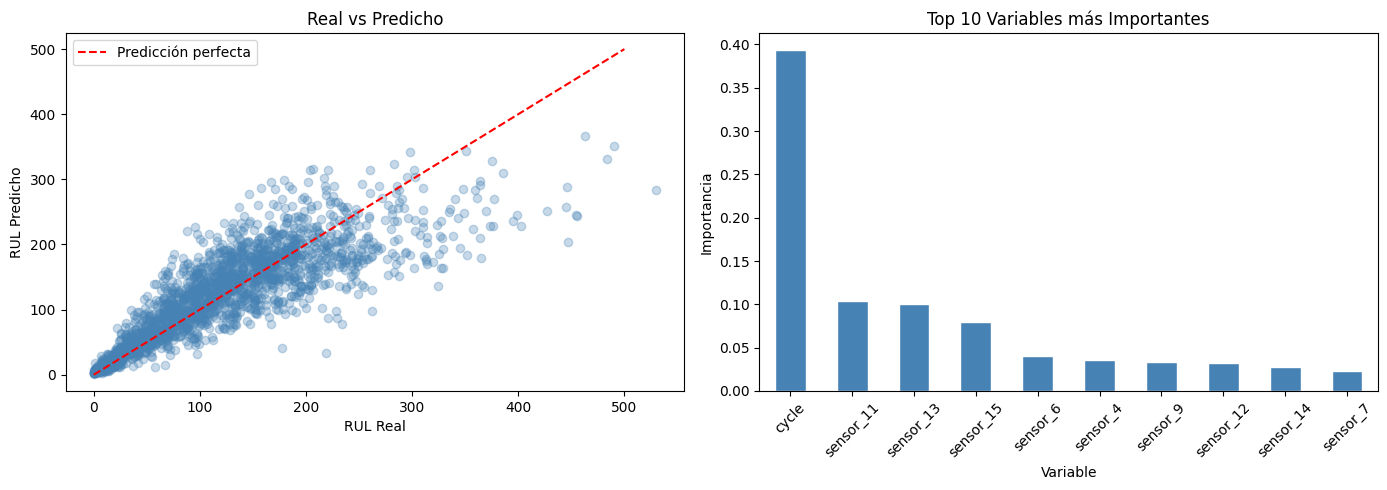

: 

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Real vs Predicho
axes[0].scatter(y_test[:2000], y_pred[:2000], alpha=0.3, color='steelblue')
axes[0].plot([0, 500], [0, 500], color='red', linestyle='--', label='Predicción perfecta')
axes[0].set_xlabel('RUL Real')
axes[0].set_ylabel('RUL Predicho')
axes[0].set_title('Real vs Predicho')
axes[0].legend()

# Importancia de variables
importancias = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)
importancias.head(10).plot(kind='bar', ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('Top 10 Variables más Importantes')
axes[1].set_xlabel('Variable')
axes[1].set_ylabel('Importancia')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
model2 = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model2.fit(X_train, y_train)

y_pred2 = model2.predict(X_test)
mae  = mean_absolute_error(y_test, y_pred2)
rmse = np.sqrt(mean_squared_error(y_test, y_pred2))
r2   = r2_score(y_test, y_pred2)

print("=" * 40)
print("📊 RESULTADOS CON RUL CAP = 125")
print("=" * 40)
print(f"MAE:  {mae:.2f} ciclos")
print(f"RMSE: {rmse:.2f} ciclos")
print(f"R²:   {r2:.4f}")

# Comparación
print("\n" + "=" * 40)
print("📊 COMPARACIÓN")
print("=" * 40)
print(f"{'Métrica':<10} {'Sin CAP':>10} {'Con CAP':>10}")
print("-" * 30)
print(f"{'R²':<10} {'0.7137':>10} {r2:>10.4f}")

📊 RESULTADOS CON RUL CAP = 125
MAE:  30.96 ciclos
RMSE: 44.61 ciclos
R²:   0.7137

📊 COMPARACIÓN
Métrica       Sin CAP    Con CAP
------------------------------
R²             0.7137     0.7137


: 

In [ ]:

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Recargar datos
path = "/home/vscode/.cache/kagglehub/datasets/behrad3d/nasa-cmaps/versions/1/CMaps"
columnas = ['unit_id', 'cycle', 'op_setting_1', 'op_setting_2', 'op_setting_3'] + \
           [f'sensor_{i}' for i in range(1, 22)]

df1 = pd.read_csv(f"{path}/train_FD001.txt", sep='\s+', header=None, names=columnas)
df2 = pd.read_csv(f"{path}/train_FD002.txt", sep='\s+', header=None, names=columnas)
df3 = pd.read_csv(f"{path}/train_FD003.txt", sep='\s+', header=None, names=columnas)
df4 = pd.read_csv(f"{path}/train_FD004.txt", sep='\s+', header=None, names=columnas)

df1['dataset'] = 'FD001'
df2['dataset'] = 'FD002'
df3['dataset'] = 'FD003'
df4['dataset'] = 'FD004'

df = pd.concat([df1, df2, df3, df4], ignore_index=True)

# Crear RUL fresco
max_cycles = df.groupby(['dataset', 'unit_id'])['cycle'].max().reset_index()
max_cycles.columns = ['dataset', 'unit_id', 'max_cycle']
df = df.merge(max_cycles, on=['dataset', 'unit_id'])
df['RUL'] = df['max_cycle'] - df['cycle']
df = df.drop(columns=['max_cycle'])

# Aplicar CAP ahora
RUL_CAP = 125
df['RUL'] = df['RUL'].clip(upper=RUL_CAP)

print(f"RUL max después del cap: {df['RUL'].max()}")
print(f"RUL min: {df['RUL'].min()}")

# Variables
features = ['cycle', 'op_setting_1', 'op_setting_2', 'op_setting_3'] + \
           [f'sensor_{i}' for i in range(1, 22)]

X = df[features]
y = df['RUL']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Entrenar
model2 = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model2.fit(X_train, y_train)

# Evaluar
y_pred2 = model2.predict(X_test)
mae  = mean_absolute_error(y_test, y_pred2)
rmse = np.sqrt(mean_squared_error(y_test, y_pred2))
r2   = r2_score(y_test, y_pred2)

print("=" * 40)
print("📊 RESULTADOS CON RUL CAP = 125")
print("=" * 40)
print(f"MAE:  {mae:.2f} ciclos")
print(f"RMSE: {rmse:.2f} ciclos")
print(f"R²:   {r2:.4f}")